# Notebook 11 — Baseline vs Features Normativas (Art. 5 EU AI Act)

Compara dos versiones del modelo XGBoost en test:

| Versión | Features |
|---------|----------|
| **Baseline** | TF-IDF → SVD(100) + keywords manuales |
| **+Normativas** | TF-IDF → SVD(100) + keywords manuales + 6 features Art. 5 EU AI Act |

**Decisión al final (celda 13):** si F1-macro mejora ≥ 0.005 → adoptar features normativas.

In [1]:
import sys
import os

_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "retrain.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        os.chdir(os.path.join(_p, "classifier_dataset_fusionado"))
        break

print("cwd:", os.getcwd())
print("sys.path[0]:", sys.path[0])

cwd: c:\Users\rammu\Documents\Asignaturas Keepcoding\Proyecto final\proyecto-final\src\classifier\classifier_dataset_fusionado
sys.path[0]: c:\Users\rammu\Documents\Asignaturas Keepcoding\Proyecto final\proyecto-final\src\classifier


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

from retrain import (
    _limpiar_texto,
    _cargar_jsonl,
    _crear_features_manuales,
    _BEST_PARAMS,
)
from create_normative_features import add_normative_features, FEATURE_COLS

_NORMATIVE_COLS = FEATURE_COLS + ["article_5_flag"]
print("Imports OK")
print(f"Features normativas ({len(_NORMATIVE_COLS)}):", _NORMATIVE_COLS)

## 1. Cargar datos

In [3]:
TRAIN_JSONL  = Path("data/finetune/train.jsonl")
TEST_JSONL   = Path("data/finetune/test.jsonl")
AUGMENT_CSV  = Path("data/annex3_aumentacion.csv")
CONTRASTIVA  = Path("data/aumentacion_contrastiva.csv")

df_train = _cargar_jsonl(TRAIN_JSONL)
print(f"train.jsonl: {len(df_train)} ejemplos")

for csv_path in [AUGMENT_CSV, CONTRASTIVA]:
    if csv_path.exists():
        df_extra = pd.read_csv(csv_path)
        df_train = pd.concat([df_train, df_extra], ignore_index=True)
        print(f"{csv_path.name}: {len(df_extra)} ejemplos añadidos")
    else:
        print(f"OMITIDO (no encontrado): {csv_path.name}")

df_train = df_train.dropna(subset=["descripcion", "etiqueta"])
df_train["texto_limpio"] = df_train["descripcion"].apply(_limpiar_texto)

df_test = _cargar_jsonl(TEST_JSONL)
df_test["texto_limpio"] = df_test["descripcion"].apply(_limpiar_texto)

print(f"\nTrain total: {len(df_train)} | Test: {len(df_test)}")
print("\nDistribución train:")
print(df_train["etiqueta"].value_counts().to_string())
print("\nDistribución test:")
print(df_test["etiqueta"].value_counts().to_string())

train.jsonl: 240 ejemplos
OMITIDO (no encontrado): annex3_aumentacion.csv
aumentacion_contrastiva.csv: 20 ejemplos añadidos

Train total: 260 | Test: 60

Distribución train:
etiqueta
inaceptable        115
riesgo_minimo       83
alto_riesgo         44
riesgo_limitado     18

Distribución test:
etiqueta
inaceptable        26
riesgo_minimo      21
alto_riesgo         9
riesgo_limitado     4


## 2. Pipeline TF-IDF → SVD (fit solo sobre train)

In [4]:
X_train_text = df_train["texto_limpio"]
y_train      = df_train["etiqueta"]
X_test_text  = df_test["texto_limpio"]
y_test       = df_test["etiqueta"]

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
    token_pattern=r"(?u)\b[a-zA-ZáéíóúüñÁÉÍÓÚÜÑ]{3,}\b",
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)
print(f"TF-IDF vocabulario: {len(tfidf.vocabulary_)} términos")

svd = TruncatedSVD(n_components=100, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)
print(f"SVD varianza explicada: {svd.explained_variance_ratio_.sum():.3f}")

X_train_manual = _crear_features_manuales(X_train_text)
X_test_manual  = _crear_features_manuales(X_test_text)
print(f"Features manuales: {X_train_manual.shape[1]} columnas")

TF-IDF vocabulario: 5000 términos
SVD varianza explicada: 0.546
Features manuales: 7 columnas


## 3. Features normativas — diagnóstico de discriminación

Se aplican sobre `descripcion` (texto crudo), no sobre `texto_limpio`,
para que las regex encuentren palabras completas.

In [5]:
df_train_norm = add_normative_features(df_train, text_col="descripcion")
df_test_norm  = add_normative_features(df_test,  text_col="descripcion")

X_train_normative = df_train_norm[_NORMATIVE_COLS].to_numpy(dtype=float)
X_test_normative  = df_test_norm[_NORMATIVE_COLS].to_numpy(dtype=float)

print(f"Features normativas — train: {X_train_normative.shape}  test: {X_test_normative.shape}")

print("\n=== Activación media por clase (train) ===")
diag = df_train_norm.groupby("etiqueta")[_NORMATIVE_COLS].mean().round(3)
print(diag.to_string())

alertas = []
for col in FEATURE_COLS:
    por_clase = df_train_norm.groupby("etiqueta")[col].mean()
    otras = por_clase.drop("inaceptable", errors="ignore")
    if not otras.empty and otras.max() > 0.10:
        alertas.append(f"  ⚠  '{col}': activación {otras.max():.0%} en '{otras.idxmax()}'")

if alertas:
    print("\nAlertas (regex posiblemente demasiado amplia):")
    for a in alertas:
        print(a)
else:
    print("\n✅ Todas las features discriminan principalmente 'inaceptable'.")

Features normativas — train: (260, 6)  test: (60, 6)

=== Activación media por clase (train) ===
                 contains_subliminal  contains_exploitation_vuln  contains_social_scoring  contains_real_time_biometric  contains_predictive_profiling  article_5_flag
etiqueta                                                                                                                                                              
alto_riesgo                    0.091                       0.000                      0.0                           0.0                          0.000           0.091
inaceptable                    0.096                       0.009                      0.0                           0.0                          0.009           0.113
riesgo_limitado                0.056                       0.000                      0.0                           0.0                          0.000           0.056
riesgo_minimo                  0.000                       0.000    

c:\Users\rammu\Documents\Asignaturas Keepcoding\Proyecto final\proyecto-final\src\classifier\create_normative_features.py:120: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.lower().str.contains(pattern, regex=True, na=False).astype(int)
c:\Users\rammu\Documents\Asignaturas Keepcoding\Proyecto final\proyecto-final\src\classifier\create_normative_features.py:120: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.lower().str.contains(pattern, regex=True, na=False).astype(int)
c:\Users\rammu\Documents\Asignaturas Keepcoding\Proyecto final\proyecto-final\src\classifier\create_normative_features.py:120: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return series.str.lower().str.contains(pattern, re

## 4. Construir matrices finales de features

In [6]:
X_train_baseline   = np.hstack([X_train_svd, X_train_manual])
X_test_baseline    = np.hstack([X_test_svd,  X_test_manual])

X_train_normativas = np.hstack([X_train_svd, X_train_manual, X_train_normative])
X_test_normativas  = np.hstack([X_test_svd,  X_test_manual,  X_test_normative])

print(f"Baseline    — train: {X_train_baseline.shape}   test: {X_test_baseline.shape}")
print(f"+Normativas — train: {X_train_normativas.shape}  test: {X_test_normativas.shape}")

Baseline    — train: (260, 107)   test: (60, 107)
+Normativas — train: (260, 113)  test: (60, 113)


## 5. Entrenar ambos modelos

In [7]:
le = LabelEncoder()
y_train_enc   = le.fit_transform(y_train)
sample_weight = compute_sample_weight(class_weight="balanced", y=y_train_enc)
clases        = list(le.classes_)
print("Clases:", clases)

modelo_baseline = XGBClassifier(**_BEST_PARAMS)
modelo_baseline.fit(X_train_baseline, y_train_enc, sample_weight=sample_weight)
print("Baseline entrenado")

modelo_normativas = XGBClassifier(**_BEST_PARAMS)
modelo_normativas.fit(X_train_normativas, y_train_enc, sample_weight=sample_weight)
print("+Normativas entrenado")

Clases: ['alto_riesgo', 'inaceptable', 'riesgo_limitado', 'riesgo_minimo']
Baseline entrenado
+Normativas entrenado


## 6. Predicciones y classification report

In [8]:
y_pred_base = le.inverse_transform(modelo_baseline.predict(X_test_baseline))
y_pred_norm = le.inverse_transform(modelo_normativas.predict(X_test_normativas))

print("=" * 55)
print("BASELINE")
print("=" * 55)
print(classification_report(y_test, y_pred_base))

print("=" * 55)
print("+NORMATIVAS")
print("=" * 55)
print(classification_report(y_test, y_pred_norm))

BASELINE
                 precision    recall  f1-score   support

    alto_riesgo       0.00      0.00      0.00         9
    inaceptable       0.55      0.85      0.67        26
riesgo_limitado       0.00      0.00      0.00         4
  riesgo_minimo       0.89      0.76      0.82        21

       accuracy                           0.63        60
      macro avg       0.36      0.40      0.37        60
   weighted avg       0.55      0.63      0.58        60

+NORMATIVAS
                 precision    recall  f1-score   support

    alto_riesgo       0.00      0.00      0.00         9
    inaceptable       0.55      0.85      0.67        26
riesgo_limitado       0.00      0.00      0.00         4
  riesgo_minimo       0.89      0.76      0.82        21

       accuracy                           0.63        60
      macro avg       0.36      0.40      0.37        60
   weighted avg       0.55      0.63      0.58        60



c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

## 7. Tabla de deltas por clase

In [9]:
def _f1_por_clase(y_true, y_pred, clases):
    report = classification_report(y_true, y_pred, output_dict=True)
    return {c: report[c]["f1-score"] for c in clases + ["macro avg"]}

f1_base = _f1_por_clase(y_test, y_pred_base, clases)
f1_norm = _f1_por_clase(y_test, y_pred_norm, clases)

print(f"{'Clase':<22} {'Baseline':>10} {'Normativas':>12} {'Delta':>8}")
print("-" * 56)
for c in clases + ["macro avg"]:
    delta = f1_norm[c] - f1_base[c]
    signo = "▲" if delta > 0.001 else ("▼" if delta < -0.001 else "─")
    print(f"{c:<22} {f1_base[c]:>10.4f} {f1_norm[c]:>12.4f} {signo} {delta:>+.4f}")

Clase                    Baseline   Normativas    Delta
--------------------------------------------------------
alto_riesgo                0.0000       0.0000 ─ +0.0000
inaceptable                0.6667       0.6667 ─ +0.0000
riesgo_limitado            0.0000       0.0000 ─ +0.0000
riesgo_minimo              0.8205       0.8205 ─ +0.0000
macro avg                  0.3718       0.3718 ─ +0.0000


c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rammu\anaconda3\envs\venv_proyecto\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

## 8. Gráfico comparativo de F1 por clase

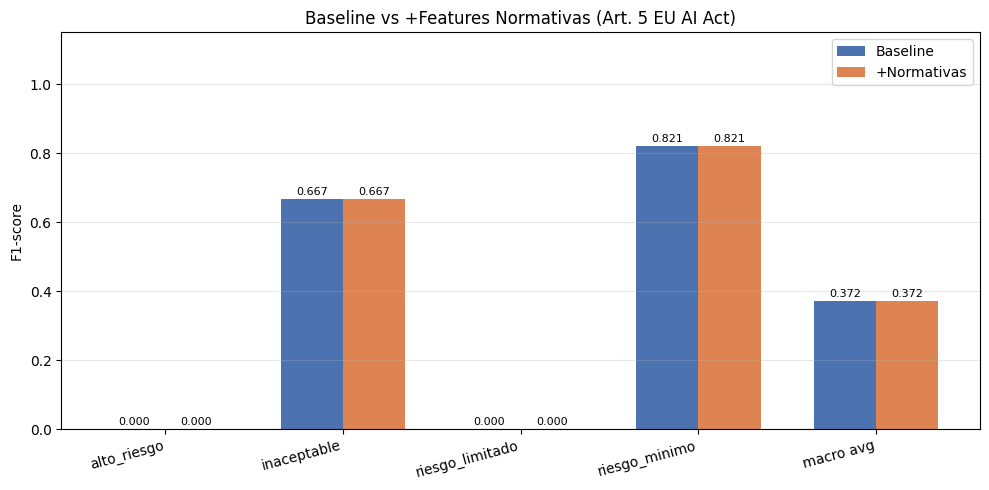

Guardado en model/comparativa_normativas.png


In [10]:
labels_plot = clases + ["macro avg"]
x     = np.arange(len(labels_plot))
width = 0.35

vals_base = [f1_base[c] for c in labels_plot]
vals_norm = [f1_norm[c] for c in labels_plot]

fig, ax = plt.subplots(figsize=(10, 5))
bars_b = ax.bar(x - width / 2, vals_base, width, label="Baseline",    color="#4C72B0")
bars_n = ax.bar(x + width / 2, vals_norm, width, label="+Normativas", color="#DD8452")

for bar in list(bars_b) + list(bars_n):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

ax.set_ylabel("F1-score")
ax.set_title("Baseline vs +Features Normativas (Art. 5 EU AI Act)")
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, rotation=15, ha="right")
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("model/comparativa_normativas.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado en model/comparativa_normativas.png")

## 9. Matrices de confusión

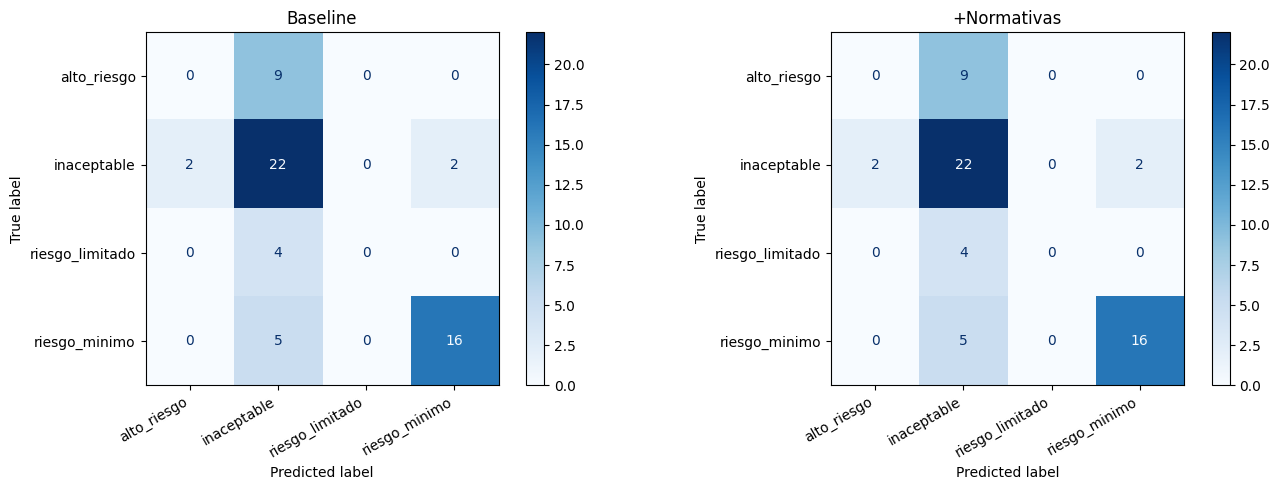

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, titulo in zip(axes, [y_pred_base, y_pred_norm], ["Baseline", "+Normativas"]):
    cm = confusion_matrix(y_test, y_pred, labels=clases)
    ConfusionMatrixDisplay(cm, display_labels=clases).plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(titulo)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 10. Ejemplos que cambian de predicción

In [ ]:
df_diff = pd.DataFrame({
    "descripcion":     df_test["descripcion"].values,
    "etiqueta_real":   y_test.values,
    "pred_baseline":   y_pred_base,
    "pred_normativas": y_pred_norm,
    "article_5_flag":  df_test_norm["article_5_flag"].values,
})

df_diff["base_ok"] = df_diff["pred_baseline"]  == df_diff["etiqueta_real"]
df_diff["norm_ok"] = df_diff["pred_normativas"] == df_diff["etiqueta_real"]
df_cambian = df_diff[df_diff["pred_baseline"] != df_diff["pred_normativas"]]

mejoran  = df_cambian[ df_cambian["norm_ok"] & ~df_cambian["base_ok"]]
empeoran = df_cambian[~df_cambian["norm_ok"] &  df_cambian["base_ok"]]

print(f"Ejemplos que cambian: {len(df_cambian)} de {len(df_diff)}")
print(f"  ▲ Mejoran:  {len(mejoran)}")
print(f"  ▼ Empeoran: {len(empeoran)}")

def _mostrar(df_sub, titulo, n=4):
    if df_sub.empty:
        return
    print(f"\n--- {titulo} ---")
    for _, row in df_sub.head(n).iterrows():
        print(f"  Real: {row['etiqueta_real']:<18} Base: {row['pred_baseline']:<18} Norm: {row['pred_normativas']}")
        print(f"  {row['descripcion'][:110]}...")

_mostrar(mejoran,  "MEJORAN")
_mostrar(empeoran, "EMPEORAN")

## 11. Decisión final

In [13]:
UMBRAL = 0.005

f1_macro_base = f1_score(y_test, y_pred_base, average="macro")
f1_macro_norm = f1_score(y_test, y_pred_norm, average="macro")
delta = f1_macro_norm - f1_macro_base

print("=" * 50)
print(f"F1-macro Baseline    : {f1_macro_base:.4f}")
print(f"F1-macro +Normativas : {f1_macro_norm:.4f}")
print(f"Delta                : {delta:+.4f}")
print("=" * 50)

if delta >= UMBRAL:
    print("\n✅ ADOPTAR features normativas")
    print("   Siguiente paso: añadir bloque 7b en retrain.py (ver Dia12.md)")
    print("   y ejecutar: python -m src.classifier.retrain")
elif delta <= -UMBRAL:
    print("\n❌ NO adoptar — las features normativas empeoran el modelo")
    print("   Revisar alertas de activación en la celda de diagnóstico.")
else:
    print("\n─  Sin mejora significativa (delta < 0.005)")
    print("   Las features no aportan ni restan. Omitirlas.")
    print("   Ejecutar retrain.py solo con la augmentación contrastiva:")
    print("   python -m src.classifier.retrain")

F1-macro Baseline    : 0.3718
F1-macro +Normativas : 0.3718
Delta                : +0.0000

─  Sin mejora significativa (delta < 0.005)
   Las features no aportan ni restan. Omitirlas.
   Ejecutar retrain.py solo con la augmentación contrastiva:
   python -m src.classifier.retrain
